# Evaluation Report: XGBOOST

This notebook loads the trained `xgboost` model, evaluates it on the test dataset, and generates SHAP explainability visualisations.

In [1]:
import sys
import os
import joblib
import numpy as np
sys.path.insert(0, os.path.abspath("../.."))
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("."))
import config
from app.ml.preprocessing import load_and_clean
from app.ml.train_all_models import add_feature_engineering, predict_with_thresholds
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import shap
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 6)

print("Loading Data...")
X, y, feature_names, drug_names, scaler, microbe_cols = load_and_clean()
X = X.astype(np.float32)
X = add_feature_engineering(X)
X = X.astype(np.float32)
y = y.astype(np.float32)

all_feature_names = feature_names + [
    "age_x_diabetes", "age_x_hypertension", "age_x_hospital",
    "age_x_infection", "infection_x_hospital", "infection_x_diabetes",
    "diabetes_x_hypertension", "diabetes_x_hospital", "hypertension_x_hospital",
    "comorbidity_count", "risk_score", "age_squared", "infection_squared"
]

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.15, random_state=42)
print("Data Loaded Successfully.")


Loading Data...


Data Loaded Successfully.


In [2]:
print("Evaluating XGBOOST Model...")
model_path = os.path.join(config.DATA_MODELS, "xgboost_model.pkl")
thresh_path = os.path.join(config.DATA_MODELS, "xgboost_thresholds.pkl")

if os.path.exists(model_path):
    model = joblib.load(model_path)
    thresholds = joblib.load(thresh_path)
    
    y_pred = predict_with_thresholds(model, X_test, thresholds)
    
    print("\n### Classification Report ###\n")
    report = classification_report(y_test, y_pred, target_names=drug_names, zero_division=0)
    print(report)
else:
    print(f"Model file for xgboost not found at {model_path}")


Evaluating XGBOOST Model...



### Classification Report ###

                   precision    recall  f1-score   support

          AMX/AMP       0.65      0.95      0.77      1185
              AMC       0.63      0.93      0.75      1139
               CZ       0.61      0.94      0.74      1126
              FOX       0.61      0.97      0.75      1135
          CTX/CRO       0.61      0.99      0.75      1138
              IPM       0.65      0.88      0.75      1156
              GEN       0.20      0.50      0.28       370
               AN       0.21      0.62      0.31       363
Acide nalidixique       0.19      0.66      0.30       265
              ofx       0.19      0.36      0.25       267
              CIP       0.21      0.58      0.31       275
                C       0.20      0.36      0.25       269
   Co-trimoxazole       0.20      0.53      0.29       281
          Furanes       0.18      0.48      0.26       250
        colistine       0.18      0.59      0.27       270

        micro avg     


### SHAP Evaluation Matrix ###


--- SHAP Feature Importance for AMX/AMP ---


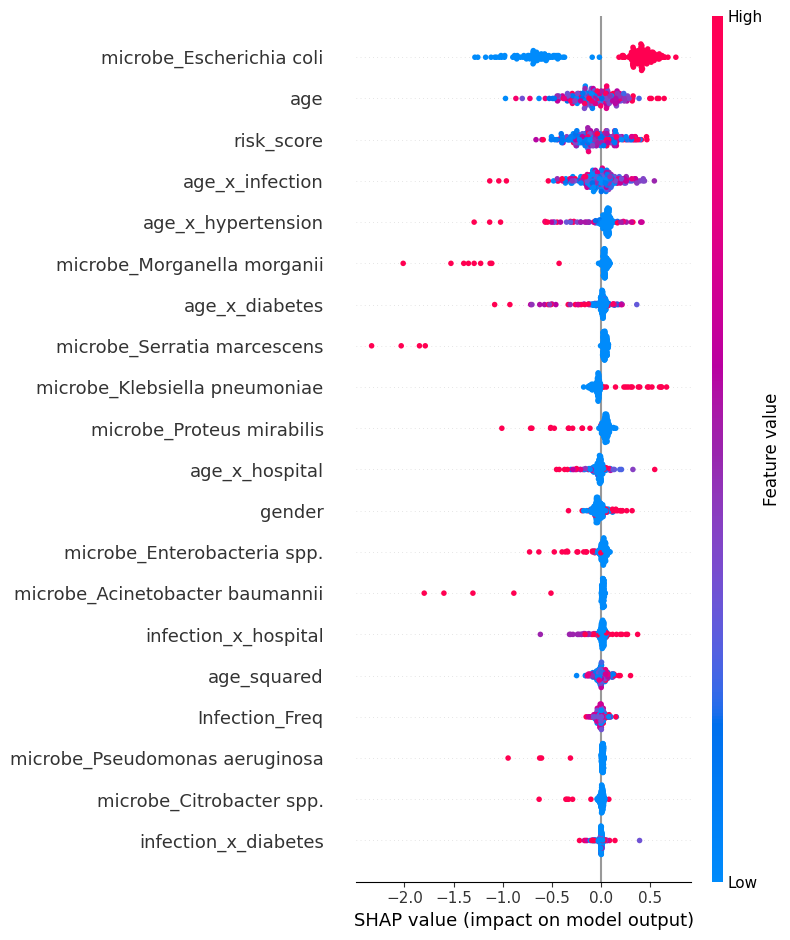


--- SHAP Feature Importance for AMC ---


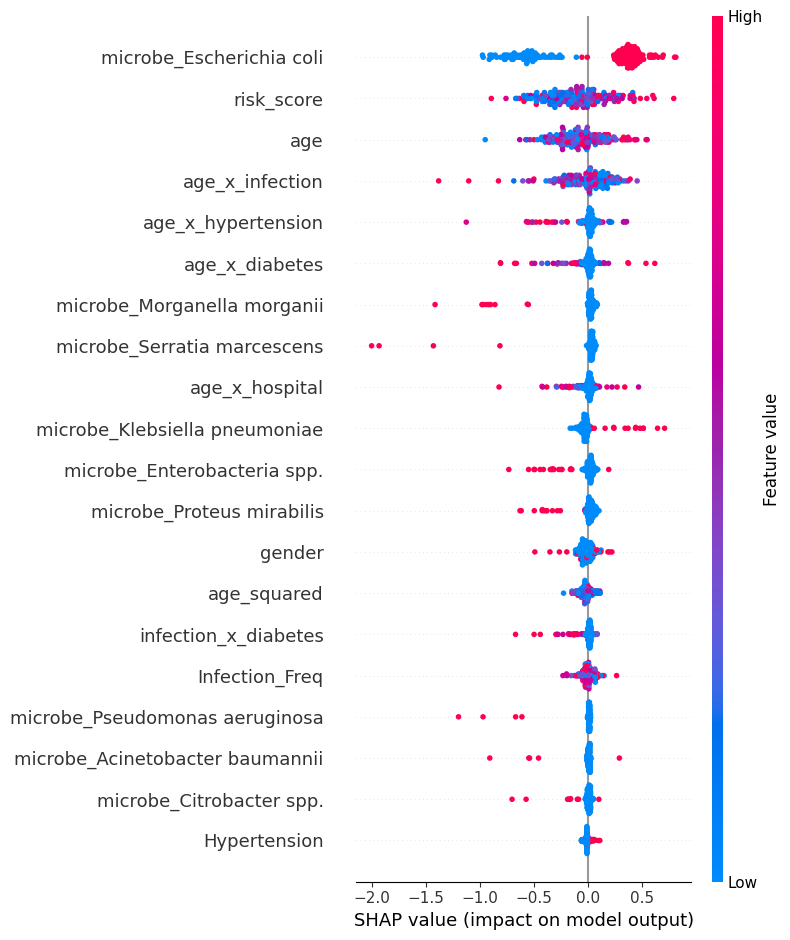


--- SHAP Feature Importance for CZ ---


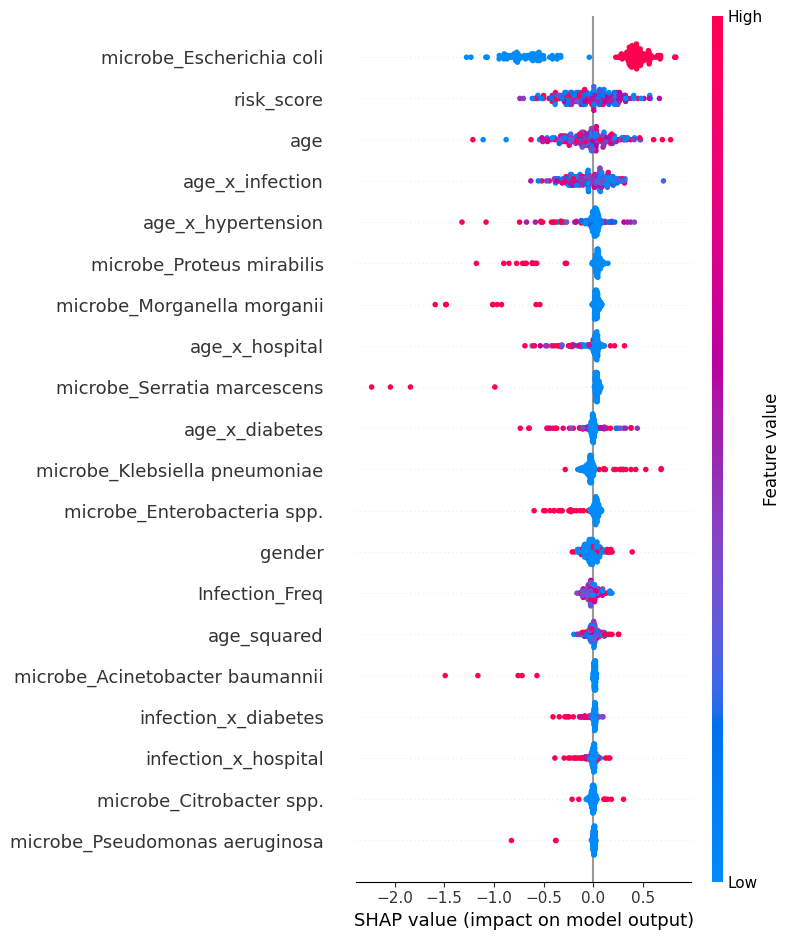


--- SHAP Feature Importance for FOX ---


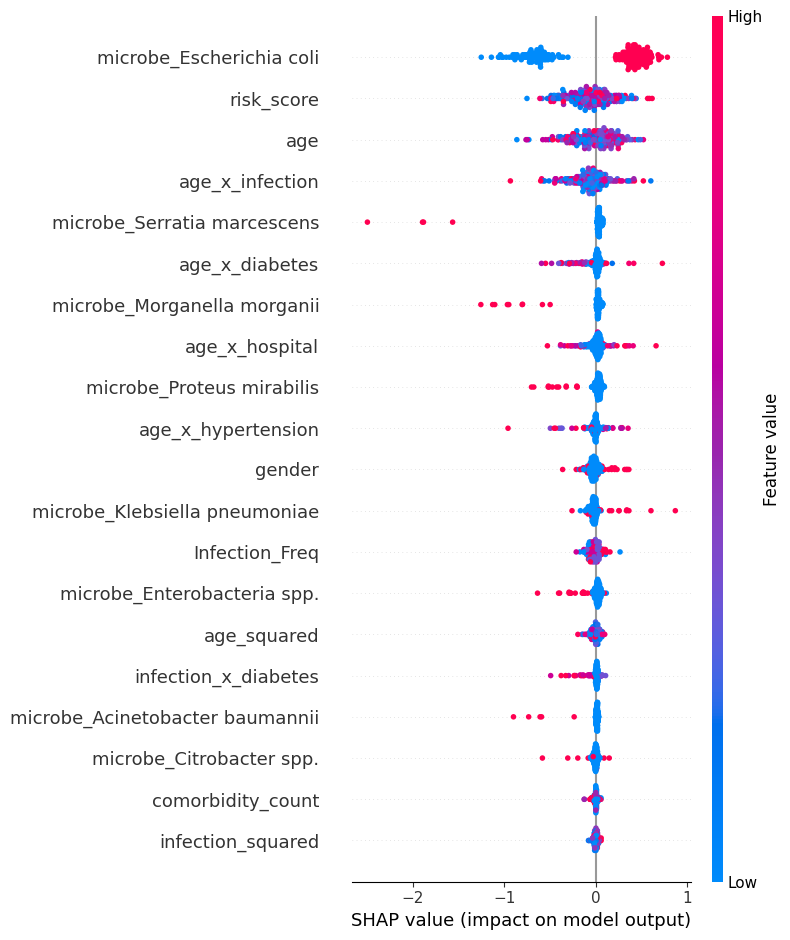


--- SHAP Feature Importance for CTX/CRO ---


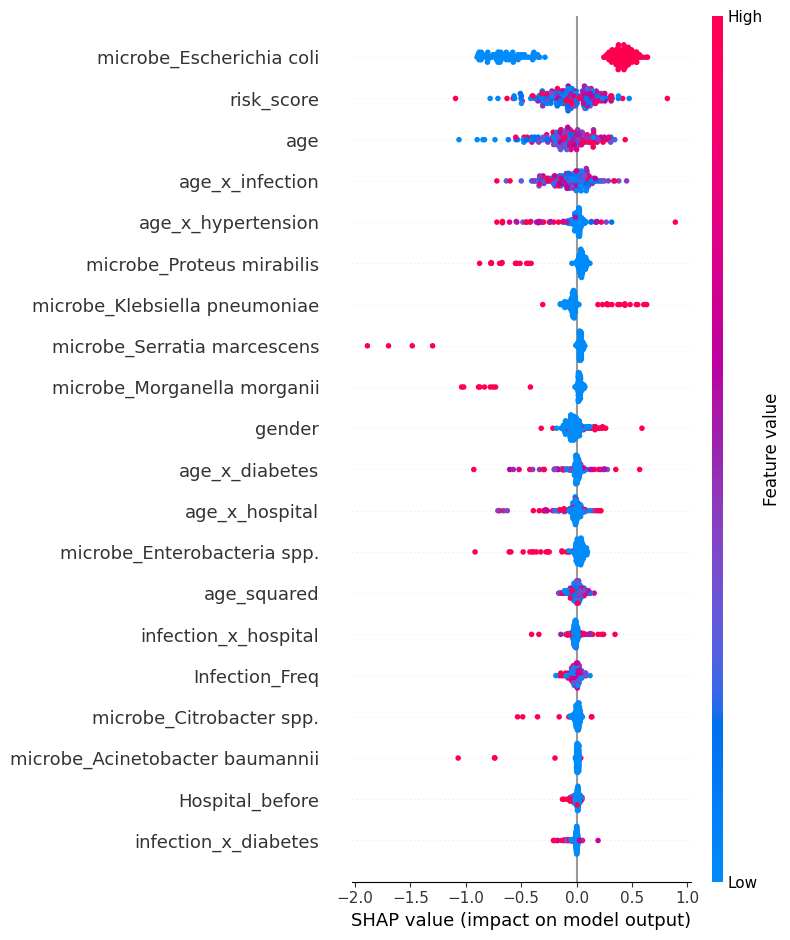

In [3]:
import warnings
warnings.filterwarnings('ignore')

if "xgboost" not in ["mlp", "svm", "ft_bilstm"]:
    print("\n### SHAP Evaluation Matrix ###\n")
    try:
        sample = X_test[:200]
        # Generate SHAP for a few top drugs to prevent enormous notebooks
        for i, (est, drug) in enumerate(zip(model.estimators_[:5], drug_names[:5])):
            print(f"\n--- SHAP Feature Importance for {drug} ---")
            explainer = shap.TreeExplainer(est)
            shap_values = explainer.shap_values(sample)
            if isinstance(shap_values, list):
                sv = shap_values[1] if len(shap_values) > 1 else shap_values[0]
            else:
                sv = shap_values
                
            plt.figure(figsize=(10, 6))
            shap.summary_plot(sv, sample, feature_names=all_feature_names, show=False)
            plt.tight_layout()
            plt.show()
    except Exception as e:
        print("SHAP Computation failed:", e)
else:
    print("\n### SHAP TreeExplainer Not Supported ###")
    print("Linear/Neural models are omitted from SHAP TreeExplainability in this automated pipeline.")
